In [1]:
from pathlib import Path
import polars as pl
from imd_features.config import FeatureSetConfig
from imd_features.inspect import (
    group_summary,
    correlation_between_groups,
    distribution_plot,
)
import json
from project_paths import paths

output_dir = paths.output

In [2]:
config_files = output_dir.glob("*_config.json")


feature_sets = {}
for config_path in config_files:
    config = FeatureSetConfig.model_validate_json(config_path.read_text())
    df = pl.read_parquet(output_dir / f"{config.output_name}.parquet")
    feature_sets[config.output_name] = {"config": config, "df": df}

print(f"Loaded {len(feature_sets)} feature sets")


for name in feature_sets:
    print(f"{name}: {feature_sets[name]['df'].shape}")

Loaded 11 feature sets
all_features_pca_50_5921e0d9: (268, 51)
all_features_unreduced_dab45356: (268, 366)
grid_factor_analysis_3_86be24c8: (268, 25)
grid_factor_analysis_5_b9988896: (268, 27)
grid_factor_analysis_8_eddd1e40: (268, 30)
grid_pca_3_cefe05c5: (268, 25)
grid_pca_5_f880f032: (268, 27)
grid_pca_8_a9290db4: (268, 30)
mixed_reduction_b78f17cd: (268, 91)
notebook_demo_f95aadbc: (268, 11)
selected_75_unreduced_69645137: (268, 66)


In [4]:
for name, fs in feature_sets.items():
    print("\n", "-"*60, "\n")
    print(name)
    print(group_summary(fs["config"], {}))


 ------------------------------------------------------------ 

all_features_pca_50_5921e0d9
shape: (1, 5)
┌───────┬────────────────┬─────────────────┬────────┬───────────┐
│ group ┆ input_features ┆ output_features ┆ scaled ┆ reduction │
│ ---   ┆ ---            ┆ ---             ┆ ---    ┆ ---       │
│ str   ┆ i64            ┆ i64             ┆ bool   ┆ str       │
╞═══════╪════════════════╪═════════════════╪════════╪═══════════╡
│ all   ┆ 365            ┆ 50              ┆ true   ┆ pca       │
└───────┴────────────────┴─────────────────┴────────┴───────────┘

 ------------------------------------------------------------ 

all_features_unreduced_dab45356
shape: (1, 5)
┌───────┬────────────────┬─────────────────┬────────┬───────────┐
│ group ┆ input_features ┆ output_features ┆ scaled ┆ reduction │
│ ---   ┆ ---            ┆ ---             ┆ ---    ┆ ---       │
│ str   ┆ i64            ┆ i64             ┆ bool   ┆ str       │
╞═══════╪════════════════╪═════════════════╪════════╪══

In [5]:
for name, fs in feature_sets.items():
    print("\n", "-"*60, "\n")
    print(name)
    print(group_summary(fs["config"], {}))


 ------------------------------------------------------------ 

all_features_pca_50_5921e0d9
shape: (1, 5)
┌───────┬────────────────┬─────────────────┬────────┬───────────┐
│ group ┆ input_features ┆ output_features ┆ scaled ┆ reduction │
│ ---   ┆ ---            ┆ ---             ┆ ---    ┆ ---       │
│ str   ┆ i64            ┆ i64             ┆ bool   ┆ str       │
╞═══════╪════════════════╪═════════════════╪════════╪═══════════╡
│ all   ┆ 365            ┆ 50              ┆ true   ┆ pca       │
└───────┴────────────────┴─────────────────┴────────┴───────────┘

 ------------------------------------------------------------ 

all_features_unreduced_dab45356
shape: (1, 5)
┌───────┬────────────────┬─────────────────┬────────┬───────────┐
│ group ┆ input_features ┆ output_features ┆ scaled ┆ reduction │
│ ---   ┆ ---            ┆ ---             ┆ ---    ┆ ---       │
│ str   ┆ i64            ┆ i64             ┆ bool   ┆ str       │
╞═══════╪════════════════╪═════════════════╪════════╪══

C:\Users\Daniel\AppData\Local\Temp\ipykernel_26096\1170925985.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Daniel\AppData\Local\Temp\ipykernel_26096\1170925985.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
c:\Users\Daniel\projects\imd_feature_engineering\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Daniel\projects\imd_feature_engineering\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\Daniel\AppData\Local\Temp\ipykernel_26096\1170925985.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
c:\Users\Daniel\projects\imd_feature_engineering\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divi

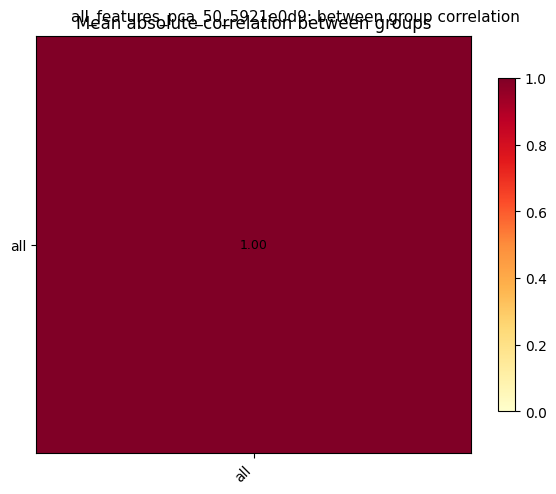

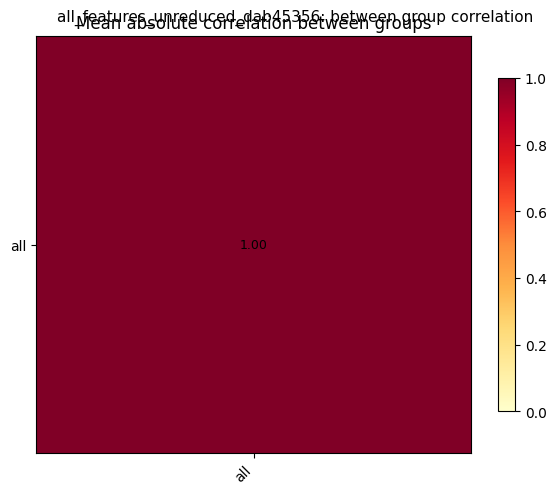

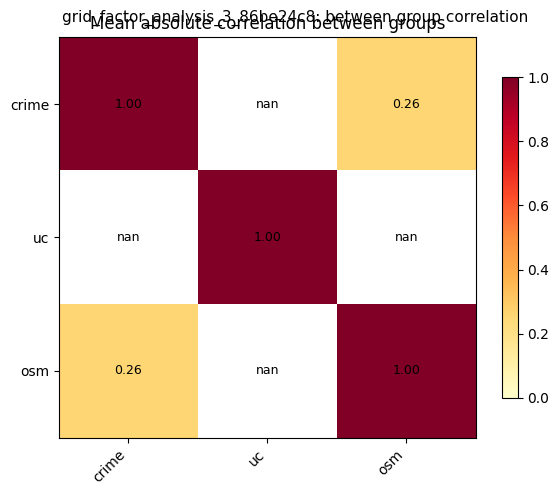

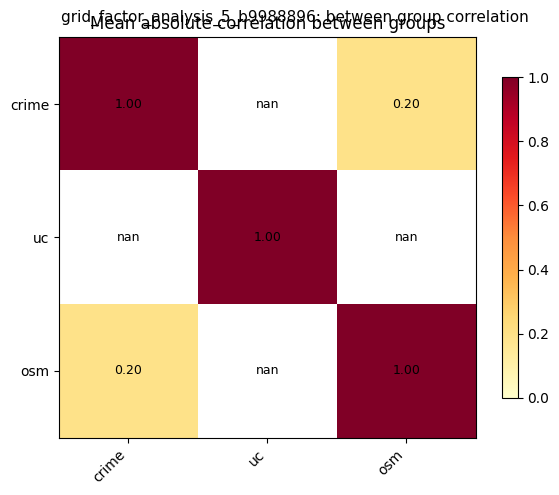

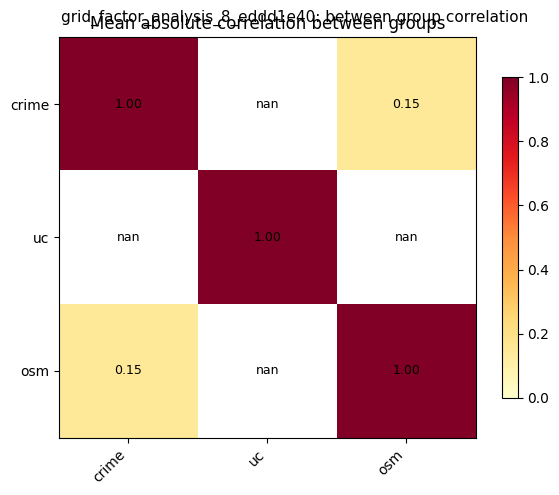

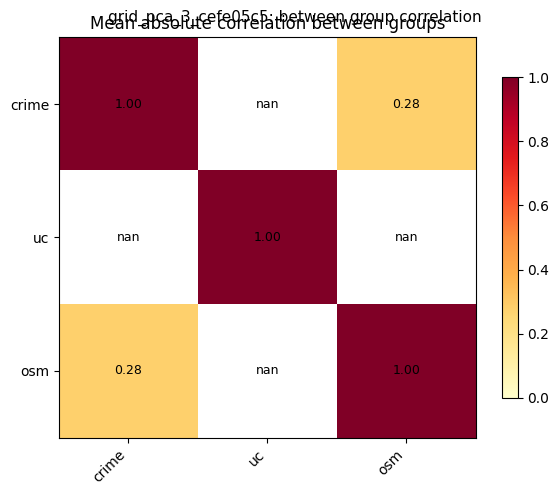

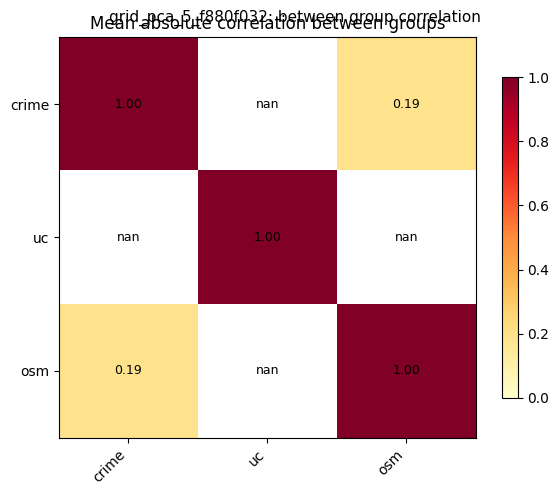

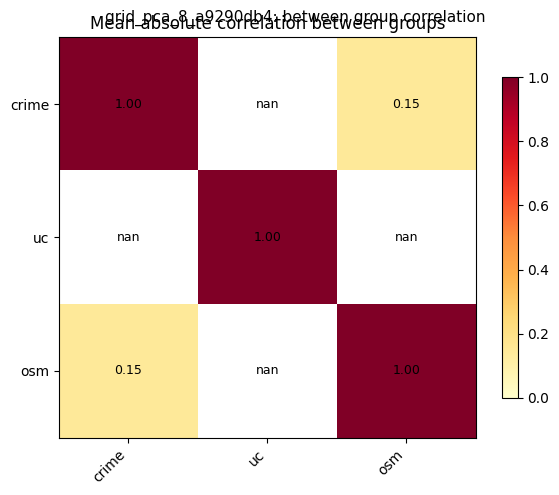

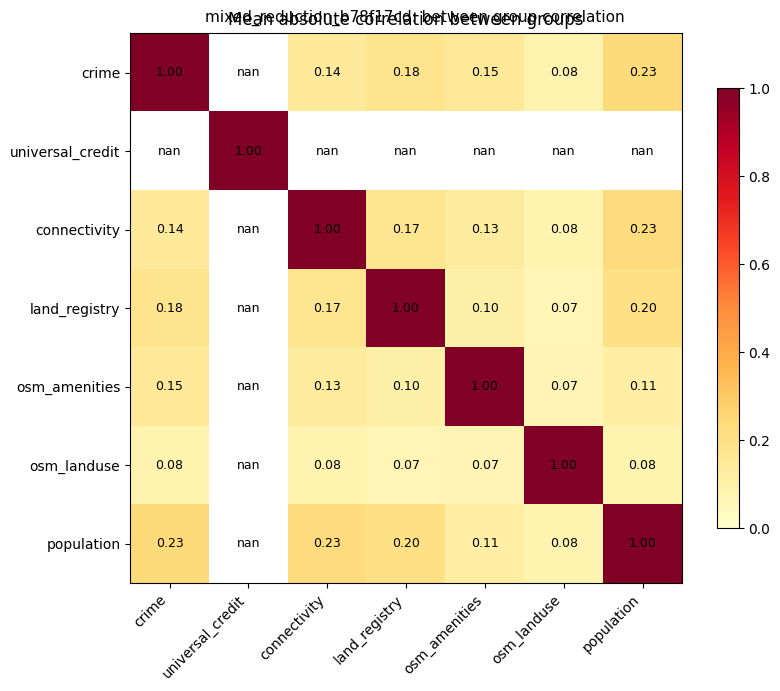

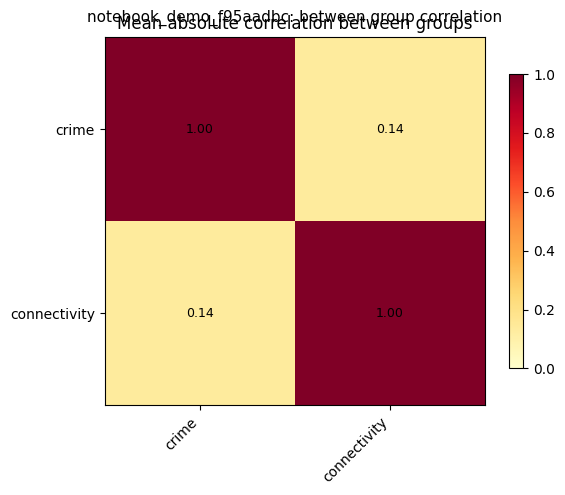

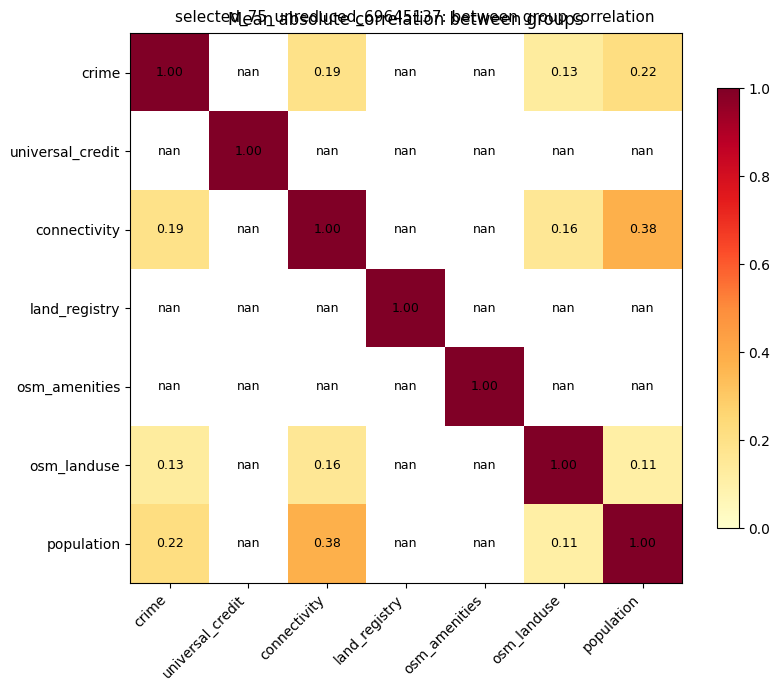

In [6]:
for name, fs in feature_sets.items():
    fig = correlation_between_groups(fs["df"], fs["config"])
    fig.suptitle(f"{name}: between group correlation", fontsize=11)
    fig.show()

C:\Users\Daniel\AppData\Local\Temp\ipykernel_26096\271201017.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Daniel\AppData\Local\Temp\ipykernel_26096\271201017.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Daniel\AppData\Local\Temp\ipykernel_26096\271201017.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Daniel\AppData\Local\Temp\ipykernel_26096\271201017.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Daniel\AppData\Local\Temp\ipykernel_26096\271201017.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Daniel\AppData\Local\Temp\ipykernel_26096\271201017.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\Daniel\AppData\Local\Temp\ipykernel_26096\271201017.py:4: UserWarni

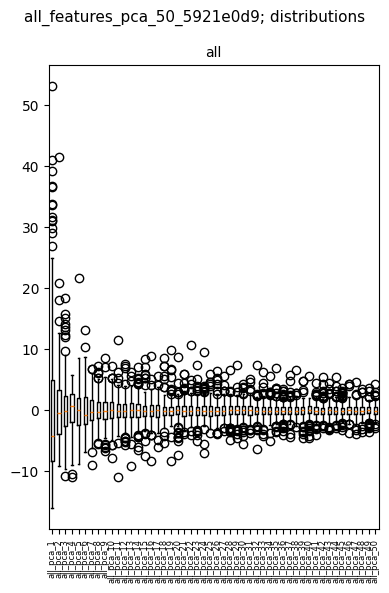

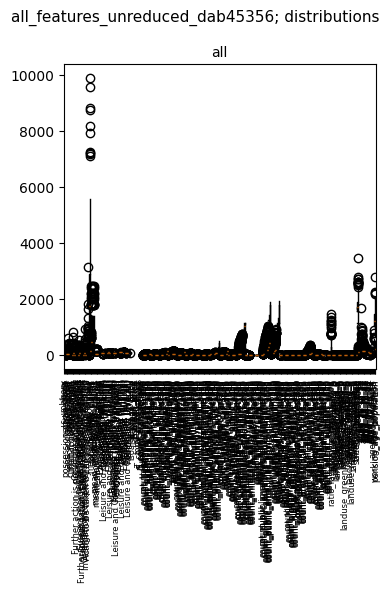

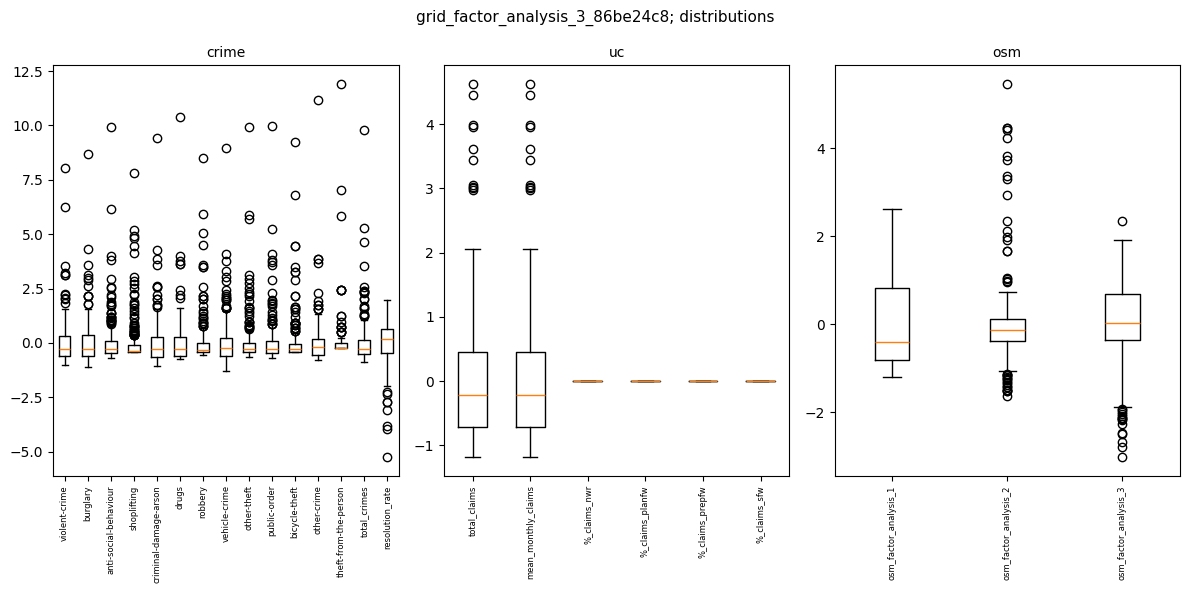

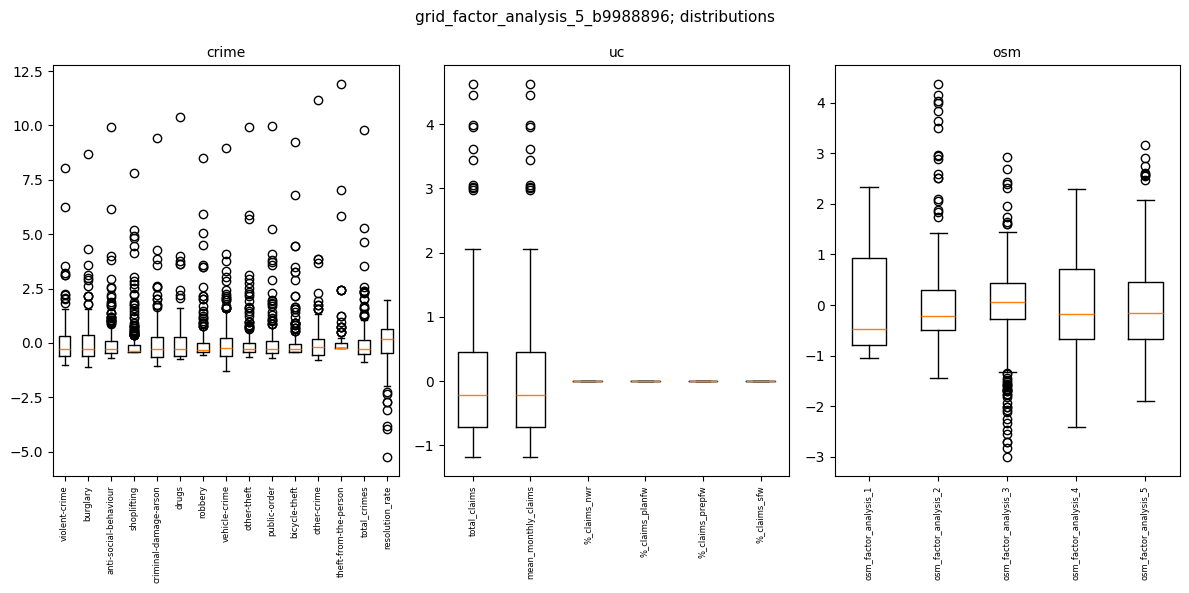

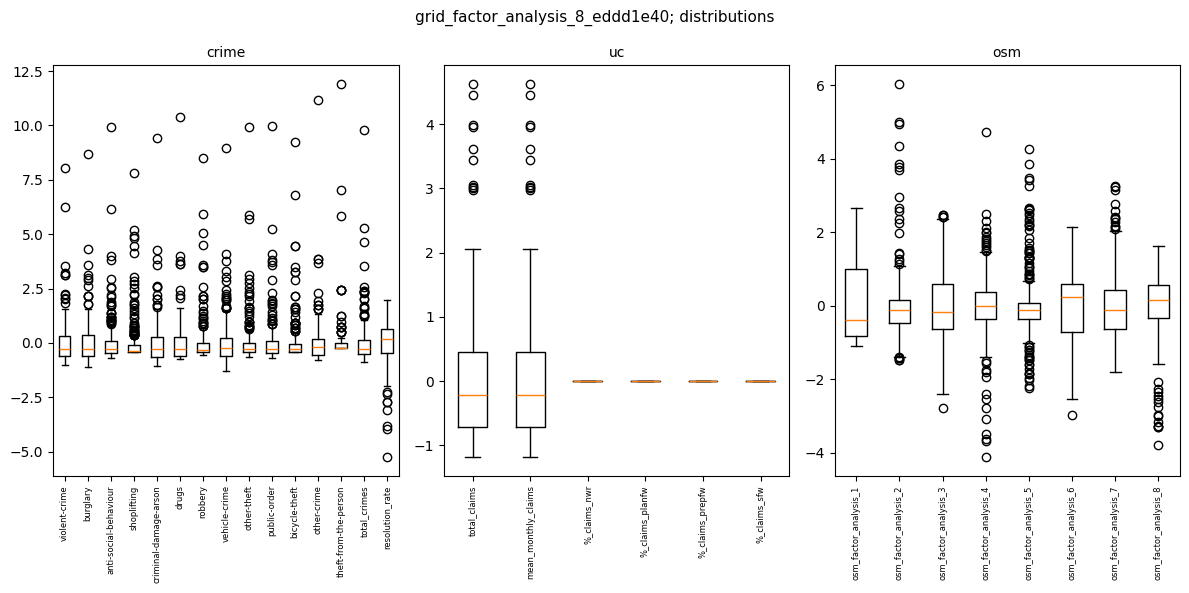

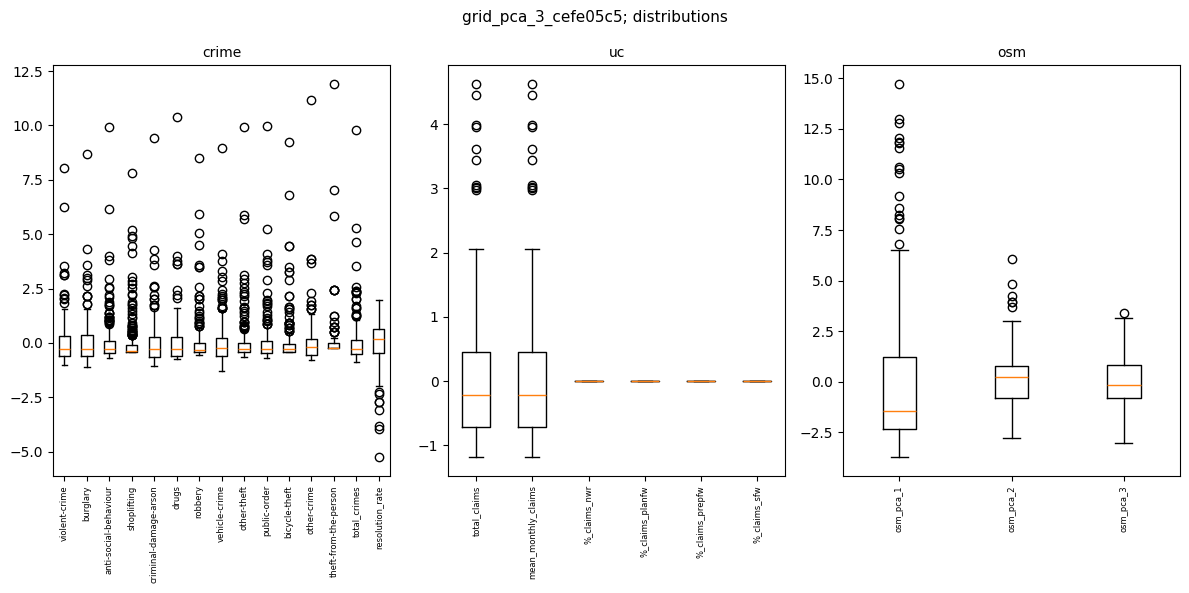

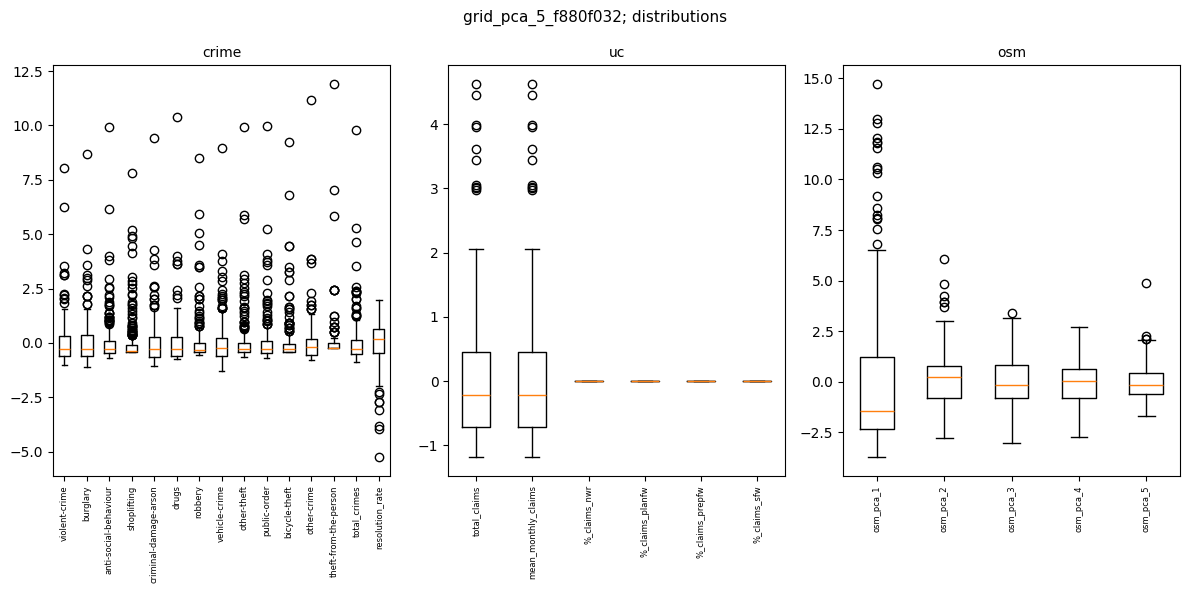

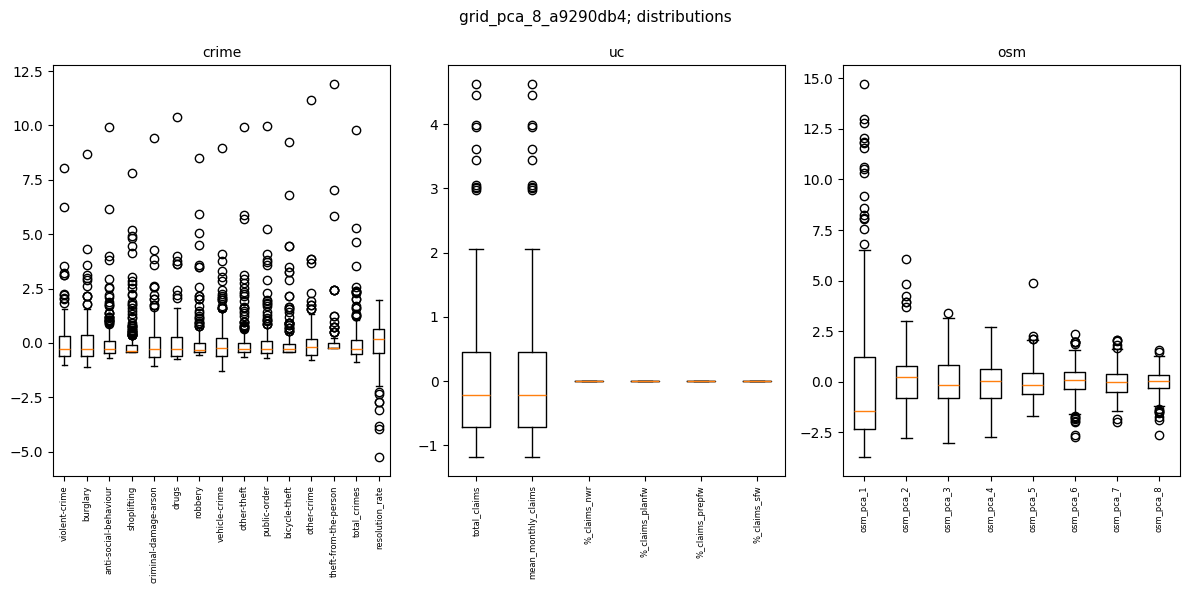

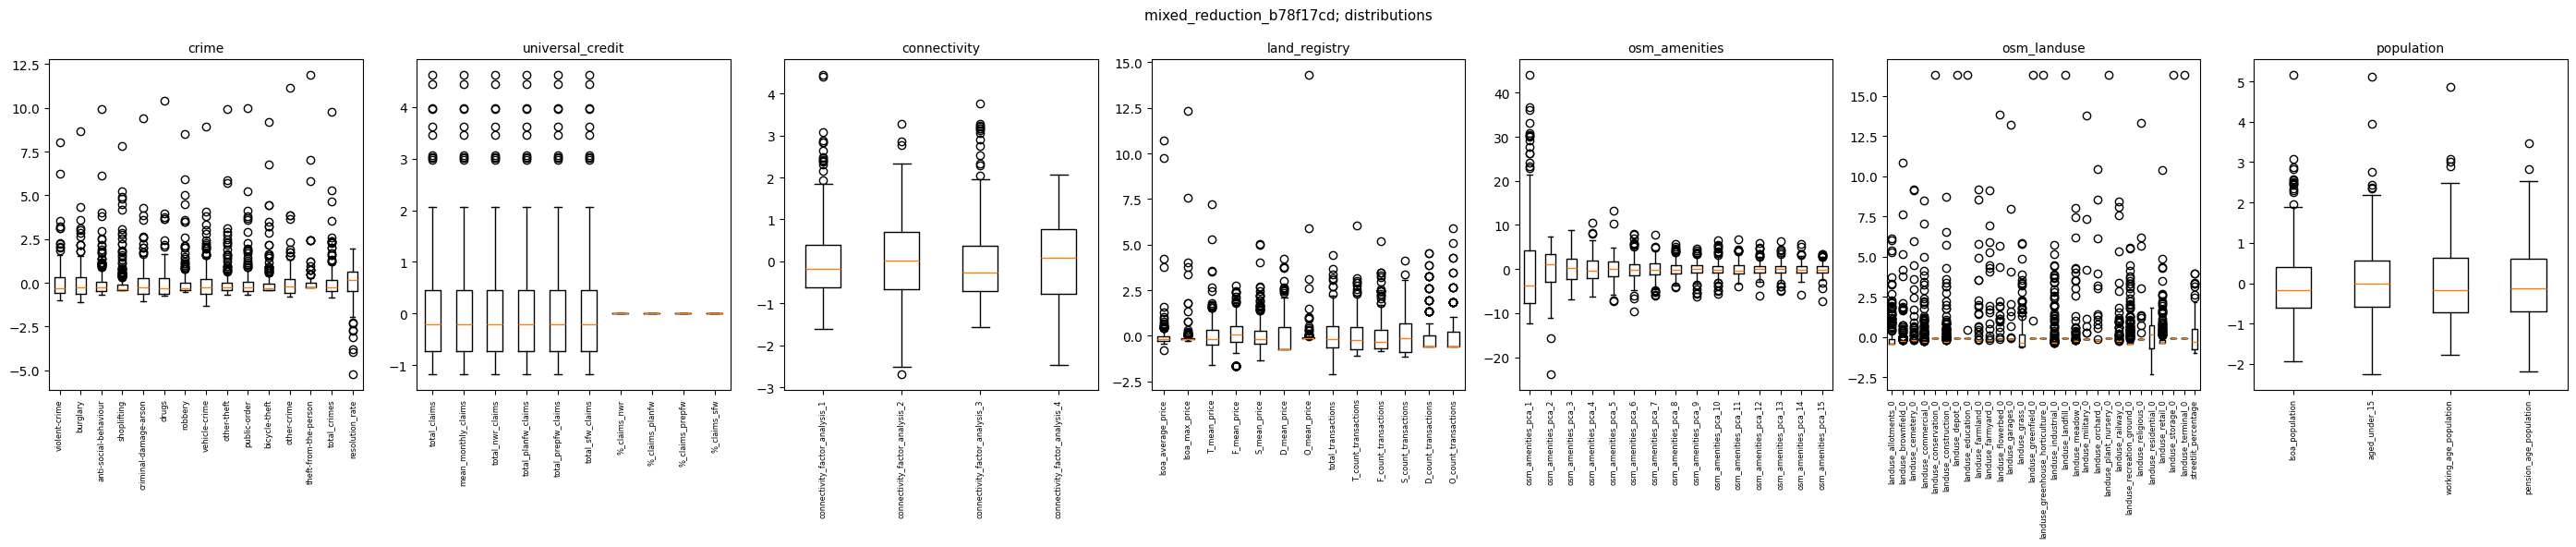

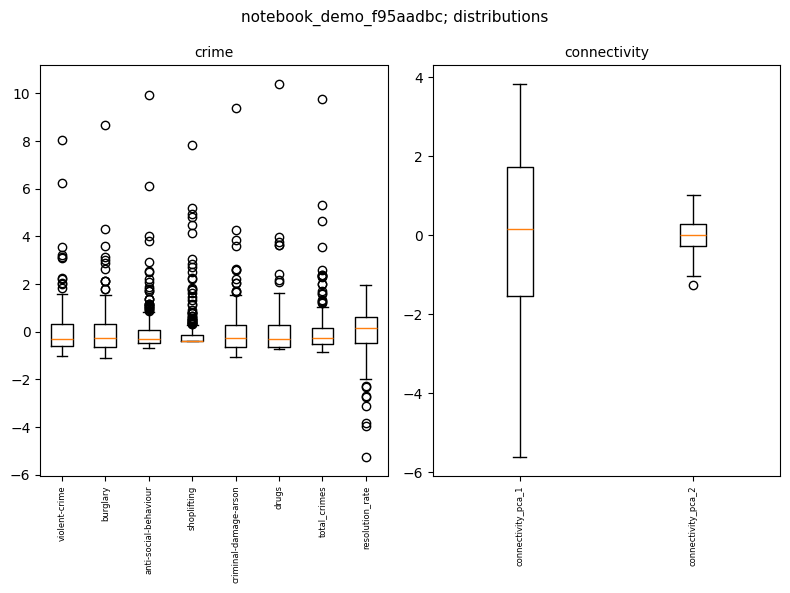

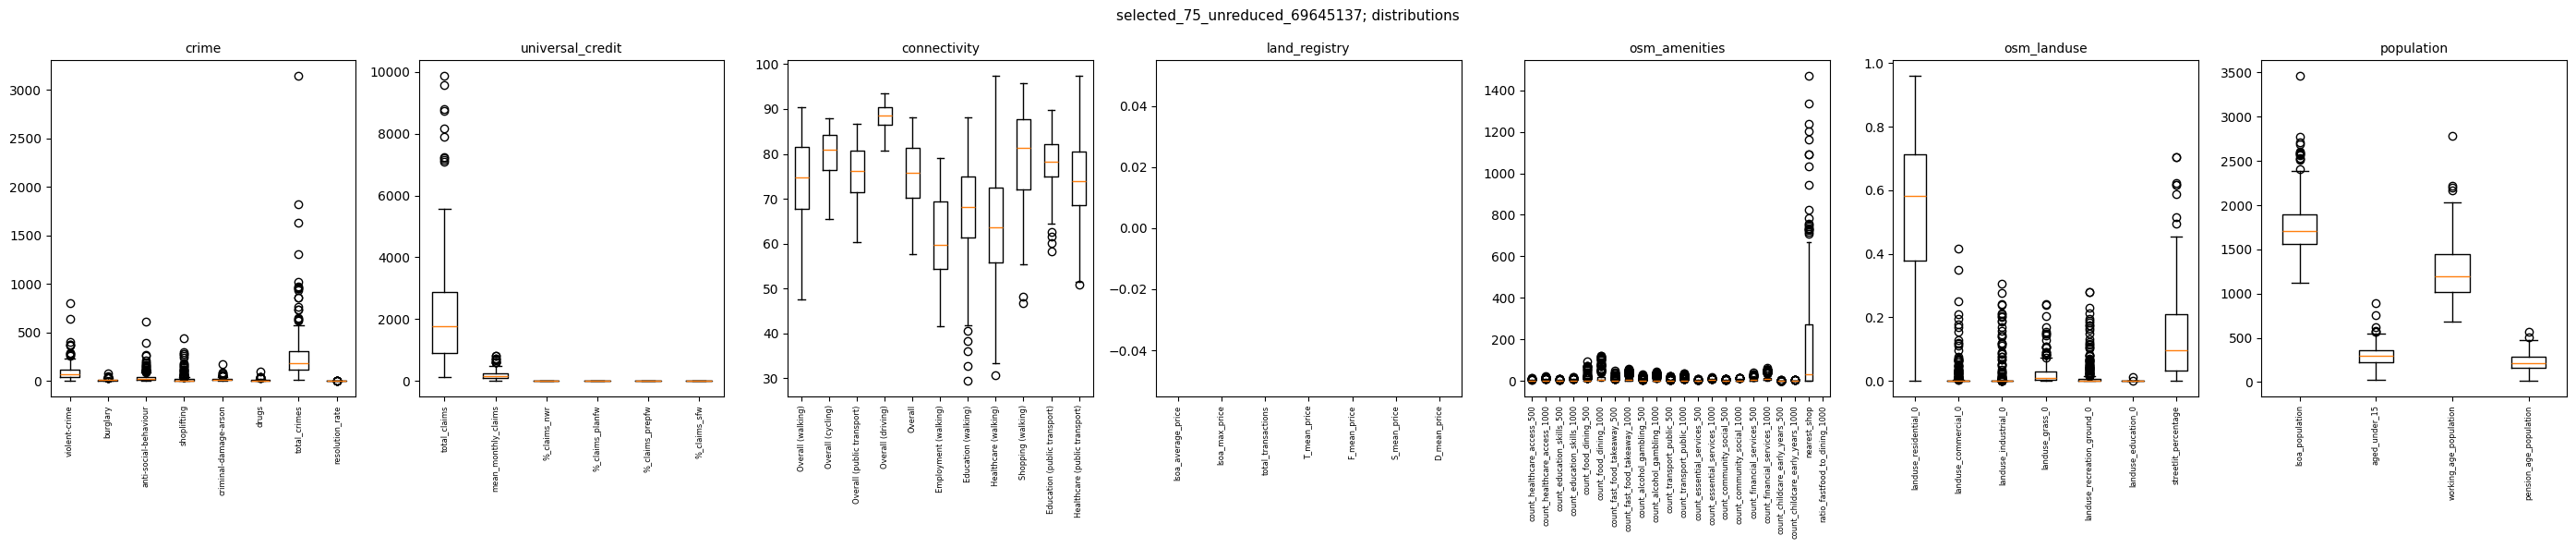

In [7]:
for name, fs in feature_sets.items():
    fig = distribution_plot(fs["df"], fs["config"])
    fig.suptitle(f"{name}; distributions", fontsize=11)
    fig.show()

In [ ]:
comparison = pl.DataFrame([
    {
        "feature_set": name,
        "rows": fs["df"].shape[0],
        "columns": fs["df"].shape[1],
        "groups": len(fs["config"].groups),
        "description": fs["config"].description,
    }
    for name, fs in feature_sets.items()
])


with pl.Config(tbl_width_chars=400, tbl_rows=200):
    print(comparison)

shape: (11, 5)
┌─────────────────────────────────┬──────┬─────────┬────────┬─────────────────────────────────┐
│ feature_set                     ┆ rows ┆ columns ┆ groups ┆ description                     │
│ ---                             ┆ ---  ┆ ---     ┆ ---    ┆ ---                             │
│ str                             ┆ i64  ┆ i64     ┆ i64    ┆ str                             │
╞═════════════════════════════════╪══════╪═════════╪════════╪═════════════════════════════════╡
│ all_features_pca_50_5921e0d9    ┆ 268  ┆ 51      ┆ 1      ┆ All features in a single group… │
│ all_features_unreduced_dab4535… ┆ 268  ┆ 366     ┆ 1      ┆ All features in a single group… │
│ grid_factor_analysis_3_86be24c… ┆ 268  ┆ 25      ┆ 3      ┆ OSM reduced with factor_analys… │
│ grid_factor_analysis_5_b998889… ┆ 268  ┆ 27      ┆ 3      ┆ OSM reduced with factor_analys… │
│ grid_factor_analysis_8_eddd1e4… ┆ 268  ┆ 30      ┆ 3      ┆ OSM reduced with factor_analys… │
│ grid_pca_3_cefe05c5    